# PCA theoretical limits

measures the reconstruction ceiling of PCA at various dimensions on the DEG+HVG gene set.
for each n_components: project to PCA space, inverse-project back, compute cosine_logfc
against original. this shows how much perturbation signal is preserved at each compression level.

In [1]:
from pathlib import Path
import json

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine as cosine_dist
from scipy.stats import wasserstein_distance

In [2]:
# load datamodule to get the same train/test split and feature set
from hydra.utils import instantiate
from omegaconf import OmegaConf

# use any existing AE run config to get the datamodule setup
# (we only need the data, not the model)
experiment_name = "sciplex_ae_deg_log1p_recon"
runs_root = Path("artifacts/runs")
run_root = runs_root / experiment_name
run_dirs = sorted(p for p in run_root.glob("*") if p.is_dir())
if not run_dirs:
    raise FileNotFoundError(f"No runs found under {run_root}")
run_dir = run_dirs[-1]
cfg = OmegaConf.load(run_dir / "run_config.yaml")

datamodule = instantiate(
    cfg.data,
    data=OmegaConf.to_container(cfg.data, resolve=True),
    splitter=OmegaConf.to_container(cfg.splitter, resolve=True),
    space=OmegaConf.to_container(cfg.space, resolve=True),
    evaluation_space=OmegaConf.to_container(cfg.evaluation_space, resolve=True),
    condition=OmegaConf.to_container(cfg.condition, resolve=True),
    paths=OmegaConf.to_container(cfg.paths, resolve=True),
    ae_geometry=OmegaConf.to_container(cfg.ae_geometry, resolve=True),
    task=OmegaConf.to_container(cfg.task, resolve=True),
    predict=OmegaConf.to_container(cfg.predict, resolve=True),
    trainer=OmegaConf.to_container(cfg.trainer, resolve=True),
    _recursive_=False,
)
datamodule.setup("fit")

# get normalized log1p data in base space (no projections)
held_out_mask = np.asarray(datamodule.masks["is_held_out"], dtype=bool)
test_adata = datamodule.adata_full[held_out_mask].copy()
train_adata = datamodule.adata_full[~held_out_mask].copy()

# transform to training space (normalized log1p on DEG+HVG genes)
x_train, lib_train, feature_names = datamodule.train_pipeline.transform(train_adata, device="cpu")
x_test, lib_test, _ = datamodule.train_pipeline.transform(test_adata, device="cpu")
x_train = np.asarray(x_train, dtype=np.float32)
x_test = np.asarray(x_test, dtype=np.float32)
feature_names = list(feature_names)

# schema for evaluation
schema = datamodule.schema
perturbation_key = str(schema.perturbation_source)
control_column = str(schema.control_column)
control_value = str(schema.control_value)
covariate_keys = tuple(str(cov.source_column) for cov in schema.sample_covariates)
dose_key = "dose"

print(f"train: {x_train.shape}, test: {x_test.shape}")
print(f"features: {len(feature_names)}")

train: (87775, 6396), test: (12225, 6396)
features: 6396


In [3]:
from flatcfm._utils import dense_array

# build control means per cell type
all_control_mask = datamodule.adata_full.obs[control_column].astype(str).to_numpy() == control_value
all_control_adata = datamodule.adata_full[all_control_mask].copy()
x_ctrl, _, _ = datamodule.train_pipeline.transform(all_control_adata, device="cpu")
x_ctrl = np.asarray(x_ctrl, dtype=np.float32)
ctrl_obs = all_control_adata.obs.copy().reset_index(drop=True)

ctrl_means = {}
for ct in ctrl_obs["cell_type"].astype(str).unique():
    m = ctrl_obs["cell_type"].astype(str).to_numpy() == ct
    ctrl_means[ct] = x_ctrl[m].mean(axis=0)

print(f"control cells: {len(x_ctrl)}")
print(f"cell types: {list(ctrl_means.keys())}")

control cells: 2196
cell types: ['MCF7', 'K562', 'A549']


In [4]:
# compute theoretical limits for each PCA dimension
from flatcfm.analysis.benchmarks.metrics import compute_w2_squared

n_components_list = [10, 25, 50, 100, 200, 500, 1000, 2000, 5000, 10000, x_train.shape[1]]
# filter out dims larger than feature count
n_components_list = [n for n in n_components_list if n <= x_train.shape[1]]

test_obs = test_adata.obs.copy().reset_index(drop=True)
pert_mask = test_obs[control_column].astype(str).to_numpy() != control_value
pert_obs = test_obs.loc[pert_mask].reset_index(drop=True)
x_test_pert = x_test[pert_mask]

# group perturbation cells
group_columns = [*covariate_keys, perturbation_key, dose_key]
group_keys = []
group_slices = []
for _, grp in pert_obs.groupby(list(group_columns), observed=True):
    if len(grp) < 2:
        continue
    idx = grp.index.to_numpy()
    group_keys.append({col: str(grp.iloc[0][col]) for col in group_columns})
    group_slices.append(idx)

print(f"perturbation groups: {len(group_keys)}")
print(f"perturbed test cells: {pert_mask.sum()}")

# precompute group means for original data (shared across all PCA dims)
orig_group_means = []
orig_logfcs = []
valid_group_mask = []
for gk, idx in zip(group_keys, group_slices):
    ct = gk.get("cell_type", "")
    ctrl_mean = ctrl_means.get(ct, x_ctrl.mean(axis=0))
    orig_mean = x_test_pert[idx].mean(axis=0)
    logfc = orig_mean - ctrl_mean
    is_valid = np.linalg.norm(logfc) > 1e-8
    orig_group_means.append(orig_mean)
    orig_logfcs.append(logfc)
    valid_group_mask.append(is_valid)

orig_logfcs = np.array(orig_logfcs)  # (n_groups, n_genes)
valid_group_mask = np.array(valid_group_mask)
print(f"valid groups (nonzero logfc): {valid_group_mask.sum()}")

all_results = []

for n_comp in n_components_list:
    label = f"{n_comp}" if n_comp < x_train.shape[1] else "all"
    print(f"PCA n_components={label}...", end=" ")

    if n_comp >= x_train.shape[1]:
        x_recon = x_test_pert
        var_explained = 1.0
    else:
        pca = PCA(n_components=n_comp)
        pca.fit(x_train)
        x_proj = pca.transform(x_test_pert)
        x_recon = pca.inverse_transform(x_proj)
        var_explained = float(pca.explained_variance_ratio_.sum())

    # vectorized cosine_logfc over all groups at once
    recon_logfcs = np.array(
        [
            x_recon[idx].mean(axis=0) - ctrl_means.get(gk.get("cell_type", ""), x_ctrl.mean(axis=0))
            for gk, idx in zip(group_keys, group_slices)
        ]
    )  # (n_groups, n_genes)

    # cosine similarity: dot / (norm * norm)
    dots = np.sum(orig_logfcs * recon_logfcs, axis=1)
    norms_orig = np.linalg.norm(orig_logfcs, axis=1)
    norms_recon = np.linalg.norm(recon_logfcs, axis=1)
    cosines = dots / (norms_orig * norms_recon + 1e-12)

    for i, (gk, idx) in enumerate(zip(group_keys, group_slices)):
        if not valid_group_mask[i]:
            continue
        w2 = np.sqrt(compute_w2_squared(x_test_pert[idx], x_recon[idx]))
        all_results.append(
            {
                "n_components": n_comp,
                "label": label,
                "var_explained": var_explained,
                **gk,
                "n_cells": len(idx),
                "cosine_logfc": float(cosines[i]),
                "w2": float(w2),
            }
        )

    mean_cos = float(cosines[valid_group_mask].mean())
    print(f"var_explained={var_explained:.4f}, mean cosine={mean_cos:.4f}")

results = pd.DataFrame(all_results)
print(f"\ntotal results: {len(results)}")

perturbation groups: 375
perturbed test cells: 12225
valid groups (nonzero logfc): 375
PCA n_components=10... var_explained=0.1268, mean cosine=0.3182
PCA n_components=25... var_explained=0.1444, mean cosine=0.3565
PCA n_components=50... var_explained=0.1605, mean cosine=0.3863
PCA n_components=100... var_explained=0.1885, mean cosine=0.4229
PCA n_components=200... var_explained=0.2389, mean cosine=0.4778
PCA n_components=500... var_explained=0.3663, mean cosine=0.5876
PCA n_components=1000... var_explained=0.5240, mean cosine=0.6997
PCA n_components=2000... var_explained=0.7488, mean cosine=0.8380
PCA n_components=5000... var_explained=0.9984, mean cosine=0.9987
PCA n_components=all... var_explained=1.0000, mean cosine=1.0000

total results: 3750


In [5]:
# summary table
summary = (
    results.groupby(["n_components", "label", "var_explained"])
    .agg(
        cosine_logfc_mean=("cosine_logfc", "mean"),
        cosine_logfc_std=("cosine_logfc", "std"),
        w2_mean=("w2", "mean"),
        w2_std=("w2", "std"),
        n_groups=("cosine_logfc", "count"),
    )
    .reset_index()
    .sort_values("n_components")
)

display(summary)

,n_components,label,var_explained,cosine_logfc_mean,cosine_logfc_std,w2_mean,w2_std,n_groups
0,10,10,0.126849,0.318157,7.177916e-02,45.680733,8.449065e-01,375
1,25,25,0.144359,0.356543,7.368434e-02,45.234538,8.470668e-01,375
2,50,50,0.160536,0.386312,7.342078e-02,44.807396,8.463112e-01,375
3,100,100,0.188467,0.422896,6.867228e-02,44.099924,8.354398e-01,375
4,200,200,0.238906,0.477768,6.074204e-02,42.835888,8.110964e-01,375
5,500,500,0.366300,0.587556,4.595619e-02,39.542073,7.566614e-01,375
6,1000,1000,0.523991,0.699713,3.157319e-02,34.959272,6.806226e-01,375
7,2000,2000,0.748751,0.838010,1.587836e-02,26.712265,5.892407e-01,375
8,5000,5000,0.998365,0.998663,3.981218e-04,2.529689,3.604186e-01,375
9,6396,all,1.000000,1.000000,7.402065e-08,0.000001,6.815730e-07,375


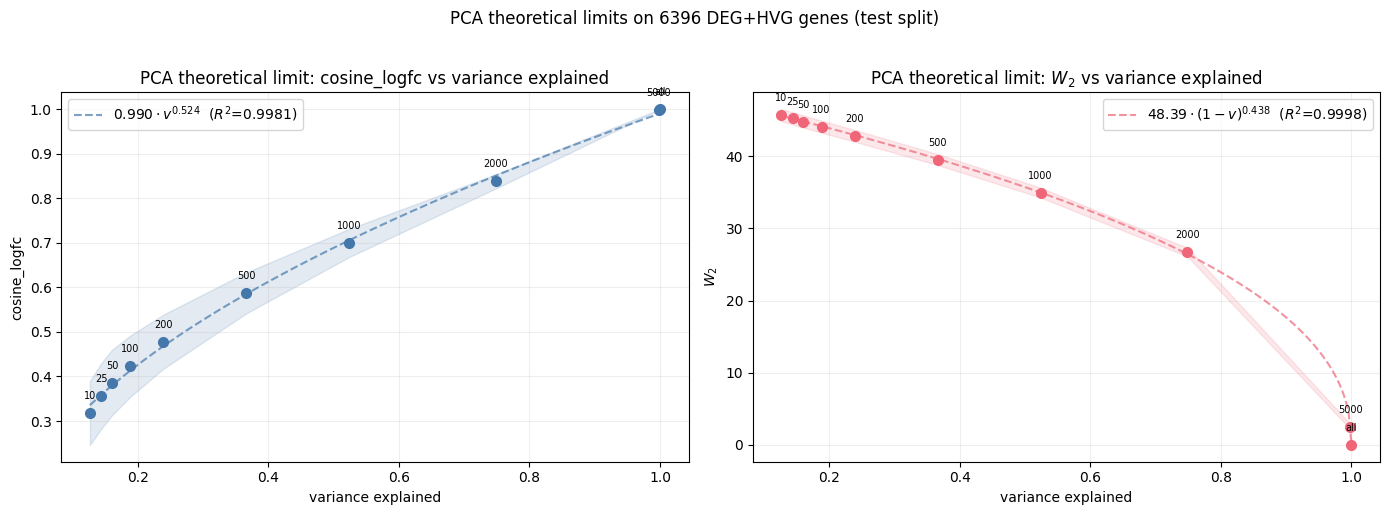

In [ ]:
# main plot: cosine_logfc and w2 vs variance explained
from scipy.optimize import curve_fit

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

s = summary.copy()
fit_mask = s["var_explained"] < 1.0


# power law: y = a * x^b
def power_law(x, a, b):
    return a * x**b


# cosine_logfc vs variance explained
ax = axes[0]
ax.plot(s["var_explained"], s["cosine_logfc_mean"], "o", color="#4477AA", markersize=7)
ax.fill_between(
    s["var_explained"],
    s["cosine_logfc_mean"] - s["cosine_logfc_std"],
    s["cosine_logfc_mean"] + s["cosine_logfc_std"],
    alpha=0.15,
    color="#4477AA",
)

x_data = s.loc[fit_mask, "var_explained"].to_numpy()
y_cos = s.loc[fit_mask, "cosine_logfc_mean"].to_numpy()
popt_cos, _ = curve_fit(power_law, x_data, y_cos, p0=[1.0, 0.5])
r2_cos = 1 - np.sum((y_cos - power_law(x_data, *popt_cos)) ** 2) / np.sum((y_cos - y_cos.mean()) ** 2)

v_smooth = np.linspace(x_data.min(), 1.0, 200)
ax.plot(
    v_smooth,
    power_law(v_smooth, *popt_cos),
    "--",
    color="#4477AA",
    alpha=0.7,
    label=f"${popt_cos[0]:.3f} \\cdot v^{{{popt_cos[1]:.3f}}}$  ($R^2$={r2_cos:.4f})",
)

ax.set_xlabel("variance explained")
ax.set_ylabel("cosine_logfc")
ax.set_title("PCA theoretical limit: cosine_logfc vs variance explained")
ax.legend()
ax.grid(alpha=0.2)
for _, row in s.iterrows():
    ax.annotate(
        f"{row['label']}",
        (row["var_explained"], row["cosine_logfc_mean"]),
        textcoords="offset points",
        xytext=(0, 10),
        fontsize=7,
        ha="center",
    )

# w2 vs variance explained
ax = axes[1]
ax.plot(s["var_explained"], s["w2_mean"], "o", color="#EE6677", markersize=7)
ax.fill_between(
    s["var_explained"],
    s["w2_mean"] - s["w2_std"],
    s["w2_mean"] + s["w2_std"],
    alpha=0.15,
    color="#EE6677",
)


# sublinear decay fit: w2 = a * (1 - v)^b
def sublinear_decay(x, a, b):
    return a * (1 - x) ** b


y_w2 = s.loc[fit_mask, "w2_mean"].to_numpy()
popt_w2, _ = curve_fit(sublinear_decay, x_data, y_w2, p0=[50.0, 0.5])
r2_w2 = 1 - np.sum((y_w2 - sublinear_decay(x_data, *popt_w2)) ** 2) / np.sum((y_w2 - y_w2.mean()) ** 2)

ax.plot(
    v_smooth,
    sublinear_decay(v_smooth, *popt_w2),
    "--",
    color="#EE6677",
    alpha=0.7,
    label=f"${popt_w2[0]:.2f} \\cdot (1-v)^{{{popt_w2[1]:.3f}}}$  ($R^2$={r2_w2:.4f})",
)

ax.set_xlabel("variance explained")
ax.set_ylabel("$W_2$")
ax.set_title("PCA theoretical limit: $W_2$ vs variance explained")
ax.legend()
ax.grid(alpha=0.2)
for _, row in s.iterrows():
    ax.annotate(
        f"{row['label']}",
        (row["var_explained"], row["w2_mean"]),
        textcoords="offset points",
        xytext=(0, 10),
        fontsize=7,
        ha="center",
    )

plt.suptitle(f"PCA theoretical limits on {len(feature_names)} DEG+HVG genes (test split)", y=1.02)
plt.tight_layout()
plt.show()

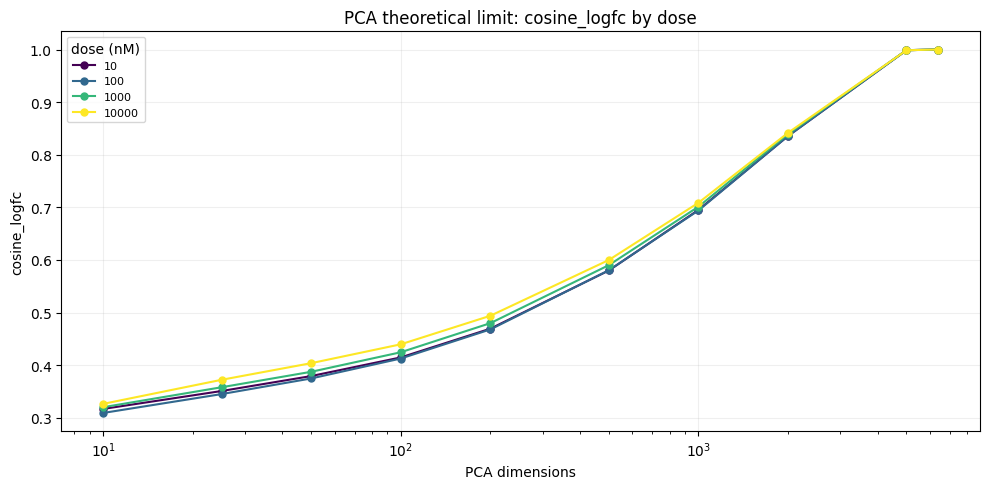


per-dose cosine_logfc:


dose_num,10.0,100.0,1000.0,10000.0
n_components,,,,
10,0.3169,0.3092,0.3201,0.3265
25,0.3509,0.3451,0.3581,0.3722
50,0.3793,0.3748,0.3875,0.4038
100,0.4148,0.4127,0.4246,0.4397
200,0.4694,0.4680,0.4799,0.4939
500,0.5800,0.5803,0.5901,0.5999
1000,0.6951,0.6941,0.7012,0.7086
2000,0.8356,0.8355,0.8393,0.8416
5000,0.9987,0.9987,0.9987,0.9986


In [7]:
# per-dose breakdown
if dose_key in results.columns:
    dose_summary = (
        results.groupby(["n_components", "label", dose_key])
        .agg(
            cosine_logfc_mean=("cosine_logfc", "mean"),
            n_groups=("cosine_logfc", "count"),
        )
        .reset_index()
    )
    dose_summary["dose_num"] = pd.to_numeric(dose_summary[dose_key], errors="coerce")

    dose_levels = sorted(dose_summary["dose_num"].dropna().unique())
    cmap = plt.cm.viridis

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, dose in enumerate(dose_levels):
        sub = dose_summary[dose_summary["dose_num"] == dose].sort_values("n_components")
        color = cmap(i / max(len(dose_levels) - 1, 1))
        ax.plot(sub["n_components"], sub["cosine_logfc_mean"], "o-", color=color, label=f"{dose:g}", markersize=5)
    ax.set_xlabel("PCA dimensions")
    ax.set_ylabel("cosine_logfc")
    ax.set_xscale("log")
    ax.legend(title="dose (nM)", fontsize=8)
    ax.grid(alpha=0.2)
    ax.set_title("PCA theoretical limit: cosine_logfc by dose")
    plt.tight_layout()
    plt.show()

    # print table
    print("\nper-dose cosine_logfc:")
    pivot = dose_summary.pivot_table(
        index="n_components",
        columns="dose_num",
        values="cosine_logfc_mean",
    ).round(4)
    display(pivot)

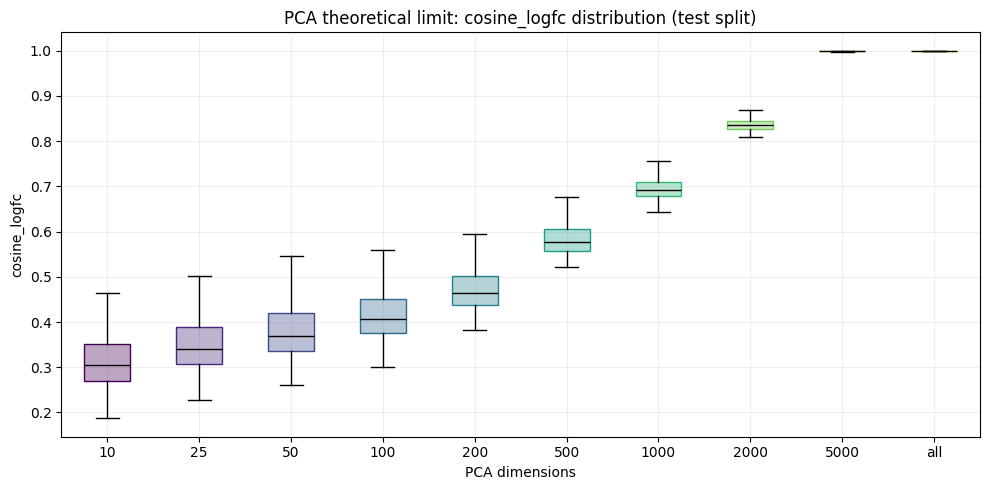

In [8]:
# boxplot distributions per n_components
comp_levels = sorted(results["n_components"].unique())
labels = [str(n) if n < len(feature_names) else "all" for n in comp_levels]

fig, ax = plt.subplots(figsize=(10, 5))
box_data = [results[results["n_components"] == n]["cosine_logfc"].dropna().to_numpy() for n in comp_levels]
bp = ax.boxplot(box_data, labels=labels, patch_artist=True, showfliers=False)
cmap = plt.cm.viridis
for i, patch in enumerate(bp["boxes"]):
    color = cmap(i / max(len(comp_levels) - 1, 1))
    patch.set_facecolor((*color[:3], 0.35))
    patch.set_edgecolor(color)
for line in bp["medians"]:
    line.set_color("black")
ax.set_xlabel("PCA dimensions")
ax.set_ylabel("cosine_logfc")
ax.set_title("PCA theoretical limit: cosine_logfc distribution (test split)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()